# Ejemplo de preprocesamiento

In [ ]:
import pandas as pd
import numpy as np
from utils import preprocess_dataset


ejemplo = pd.DataFrame({
    'edad': [25, 30, 25, np.nan, 40, 30],
    'ingresos': [50000, 60000, 50000, 55000, np.nan, 60000],
    'ciudad': ['Madrid', 'Barcelona', 'Madrid', 'Valencia', 'Barcelona', 'Barcelona'],
    'compra': ['si', 'no', 'si', 'no', 'si', 'no']   # variable objetivo
})

print("Dataset original:")
print(ejemplo)
print("\n" + "="*50 + "\n")

# Aplicamos el preprocesamiento
procesado = preprocess_dataset(ejemplo, target_col='compra')

print("\nDataset preprocesado:")
print(procesado)

# Ejemplo de Feature Selection

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from feature_selection import anova_feature_selection, intra_class_deviation, combined_ranking, plot_feature_importance
from collections import Counter
import pandas as pd

# Generar dataset sintético con 20 características, 5 informativas
X, y = make_classification(n_samples=300, n_features=20, n_informative=5,
                            n_redundant=5, n_repeated=2, n_classes=3,
                            random_state=666)
# Convertir a DataFrame
feature_names = [f'Feature_{i}' for i in range(20)]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='target')

print("="*60)
print("1. ANOVA F-test (top 10 características)")
f_scores, p_vals, top_idx = anova_feature_selection(X, y, k=10)
print("Índices top 10:", top_idx)
print("Nombres:", [feature_names[i] for i in top_idx])
print("\n")

print("="*60)
print("2. Desviación Intra-Clase (promedio ponderado)")
intra_dev, _ = intra_class_deviation(X, y)
df_intra = pd.DataFrame({'Feature': feature_names, 'Intra_class_std': intra_dev})
df_intra = df_intra.sort_values('Intra_class_std').reset_index(drop=True)
print("Características con menor desviación intra-clase (más homogéneas):")
print(df_intra.head(10))
print("\n")

print("="*60)
print("3. Ranking combinado (F - intra)")
ranking_df = combined_ranking(X, y, alpha=0.5)
print(ranking_df.head(10))

# Visualizar
plot_feature_importance(f_scores, feature_names, title='F-statistic', top_n=10)
plot_feature_importance(-intra_dev, feature_names, title='- Intra-class Std (menor es mejor)', top_n=10)
plot_feature_importance(ranking_df['Combined_score'].values, ranking_df['Feature'].values, 
                        title='Score combinado', top_n=10)

# Ejemplo de SMOTE

In [ ]:
from SMOTE import make_classification, plot_class_distribution, aplicar_smote
from sklearn.model_selection import train_test_split
from collections import Counter
import pandas as pd


# Generar dataset sintético desbalanceado (2 clases, 95% - 5%)
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                            n_redundant=5, weights=[0.95, 0.05], 
                            random_state=666)

# Convertir a DataFrame 
feature_names = [f'Feature_{i}' for i in range(20)]
X = pd.DataFrame(X, columns=feature_names)
y = pd.Series(y, name='target')

print("Distribución original de clases:")
print(Counter(y))
print()

# Dividir en entrenamiento y prueba (aplicar SMOTE solo en entrenamiento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=666, stratify=y)

print("Distribución en entrenamiento (antes de SMOTE):")
print(Counter(y_train))
print()

# Aplicar SMOTE
X_train_res, y_train_res = aplicar_smote(X_train, y_train, sampling_strategy='auto')

print("Distribución en entrenamiento (después de SMOTE):")
print(Counter(y_train_res))
print()

# Mostrar gráfico comparativo
plot_class_distribution(y_train, y_train_res, 
                        title_before='Entrenamiento (original)', 
                        title_after='Entrenamiento (con SMOTE)')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Modelo sin balanceo
clf_orig = RandomForestClassifier(random_state=666)
clf_orig.fit(X_train, y_train)
y_pred_orig = clf_orig.predict(X_test)
print("Reporte de clasificación (sin SMOTE):")
print(classification_report(y_test, y_pred_orig))

# Modelo con SMOTE
clf_smote = RandomForestClassifier(random_state=666)
clf_smote.fit(X_train_res, y_train_res)
y_pred_smote = clf_smote.predict(X_test)
print("\nReporte de clasificación (con SMOTE):")
print(classification_report(y_test, y_pred_smote))

# Ejemplo de cómo usar los métodos de validación con scikit learn

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold, LeaveOneOut, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Generar un dataset de ejemplo
X, y = make_classification(n_samples=100, n_features=5, n_informative=3,
                           n_redundant=1, n_clusters_per_class=1,
                           random_state=42)

print("Dataset shape:", X.shape)
print("Distribución de clases:", np.bincount(y))

# 2. Hold-Out (división en entrenamiento y prueba)
print("\n" + "="*50)
print("HOLD-OUT")
print("="*50)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

# Entrenar un modelo en el conjunto de entrenamiento
model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

# Predecir y evaluar en el conjunto de prueba
y_pred = model.predict(X_test)
acc_holdout = accuracy_score(y_test, y_pred)
print(f"Accuracy en hold-out: {acc_holdout:.4f}")

# 3. K-Fold Cross-Validation (K=5)
print("\n" + "="*50)
print("K-FOLD CROSS-VALIDATION (K=5)")
print("="*50)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_kfold = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
print("Accuracy por fold:", scores_kfold)
print(f"Accuracy media: {scores_kfold.mean():.4f} (+/- {scores_kfold.std() * 2:.4f})")

# 4. Leave-One-Out Cross-Validation (LOOCV)
print("\n" + "="*50)
print("LEAVE-ONE-OUT CROSS-VALIDATION (LOOCV)")
print("="*50)
loo = LeaveOneOut()
scores_loocv = cross_val_score(model, X, y, cv=loo, scoring='accuracy')
print("Número de evaluaciones LOOCV:", len(scores_loocv))
print(f"Accuracy media (LOOCV): {scores_loocv.mean():.4f}")


# Ejemplo de entrenamiento de Algoritmos con Dataset Iris


MODELO: KNN (k=1)


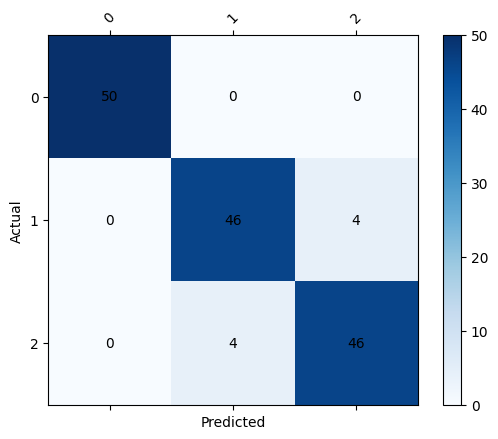

                 accuracy: 0.946667
        balanced_accuracy: 0.946667
          precision_macro: 0.946667
             recall_macro: 0.946667
                 f1_macro: 0.946667
       precision_weighted: 0.946667
          recall_weighted: 0.946667
              f1_weighted: 0.946667
                      mcc: 0.852800


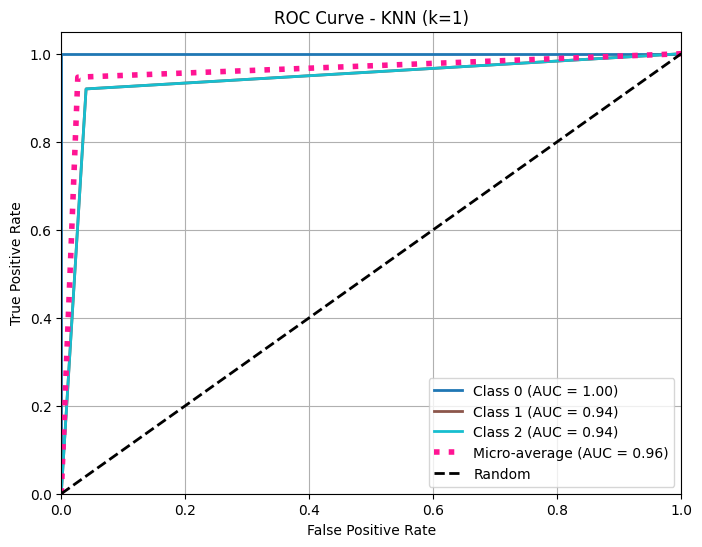


MODELO: KNN (k=3)


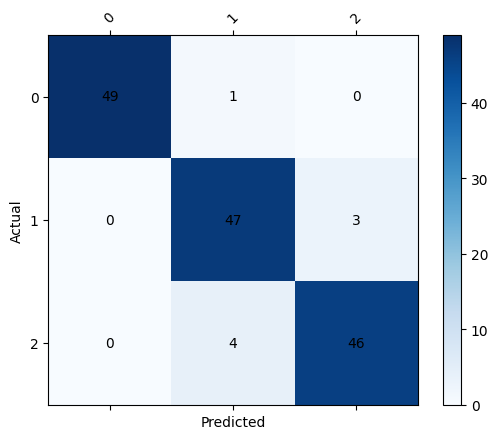

                 accuracy: 0.946667
        balanced_accuracy: 0.946667
          precision_macro: 0.947541
             recall_macro: 0.946667
                 f1_macro: 0.946920
       precision_weighted: 0.947541
          recall_weighted: 0.946667
              f1_weighted: 0.946920
                      mcc: 0.849830


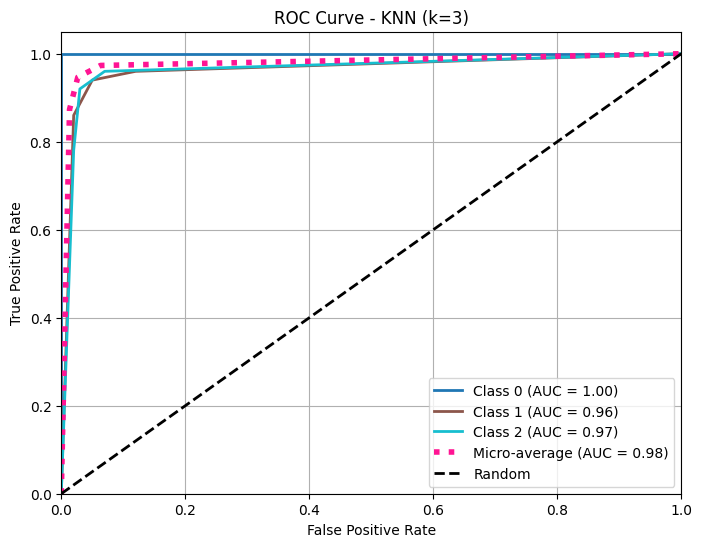


MODELO: KNN (k=5)


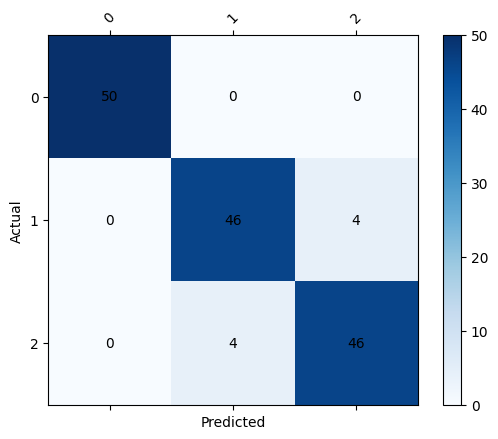

                 accuracy: 0.946667
        balanced_accuracy: 0.946667
          precision_macro: 0.946667
             recall_macro: 0.946667
                 f1_macro: 0.946667
       precision_weighted: 0.946667
          recall_weighted: 0.946667
              f1_weighted: 0.946667
                      mcc: 0.852800


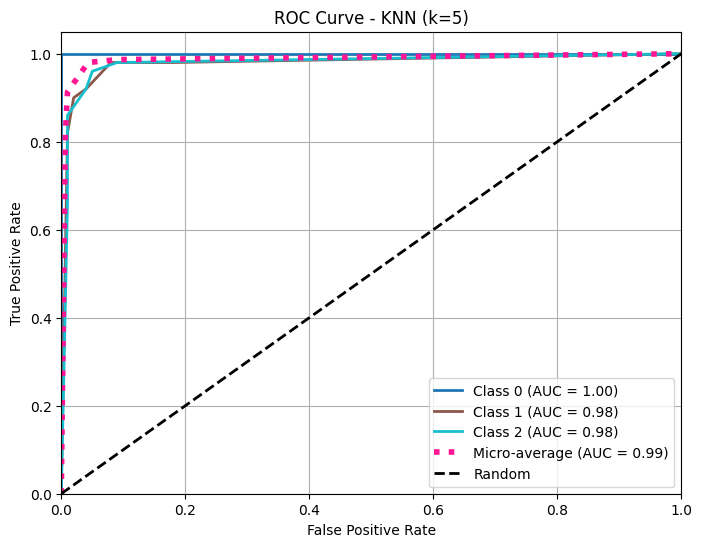


MODELO: Regresión Logística


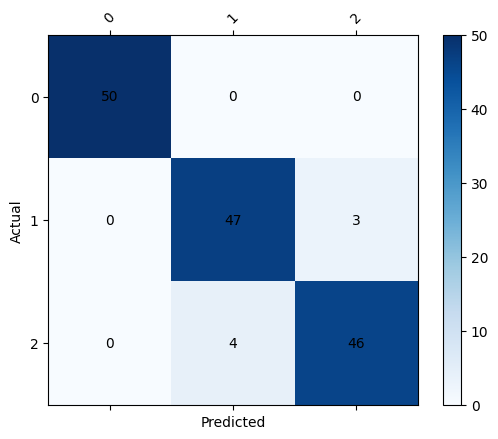

                 accuracy: 0.953333
        balanced_accuracy: 0.953333
          precision_macro: 0.953448
             recall_macro: 0.953333
                 f1_macro: 0.953329
       precision_weighted: 0.953448
          recall_weighted: 0.953333
              f1_weighted: 0.953329
                      mcc: 0.869809


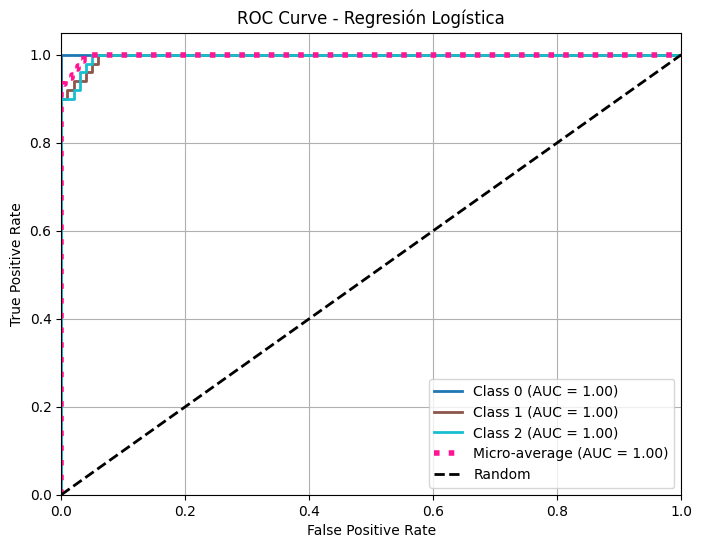


MODELO: J48 (Entropy Tree)


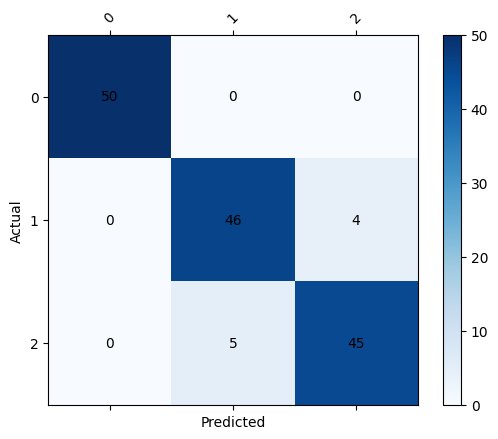

                 accuracy: 0.940000
        balanced_accuracy: 0.940000
          precision_macro: 0.940109
             recall_macro: 0.940000
                 f1_macro: 0.939994
       precision_weighted: 0.940109
          recall_weighted: 0.940000
              f1_weighted: 0.939994
                      mcc: 0.836211


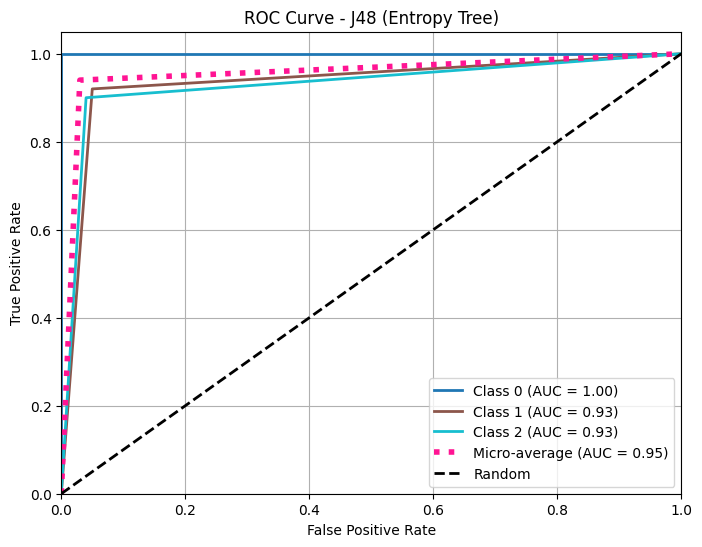


MODELO: Random Forest


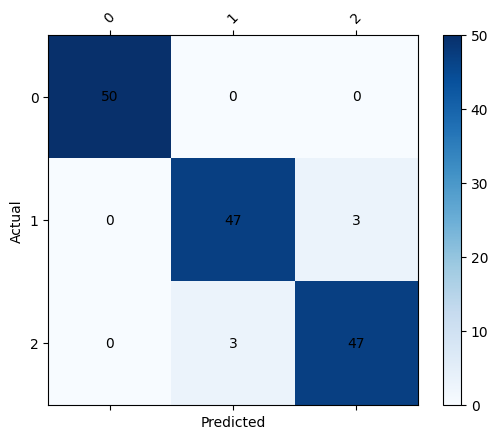

                 accuracy: 0.960000
        balanced_accuracy: 0.960000
          precision_macro: 0.960000
             recall_macro: 0.960000
                 f1_macro: 0.960000
       precision_weighted: 0.960000
          recall_weighted: 0.960000
              f1_weighted: 0.960000
                      mcc: 0.887200


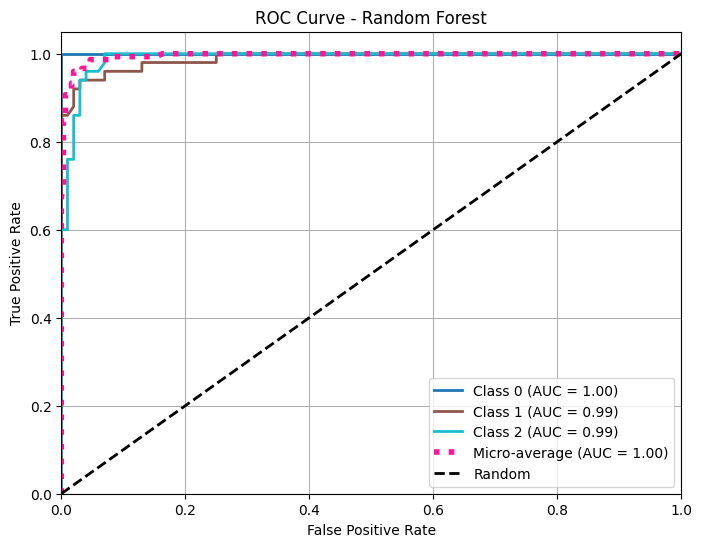


MODELO: SVM (RBF)


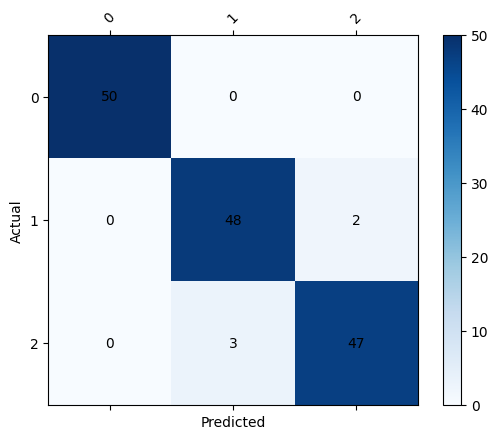

                 accuracy: 0.966667
        balanced_accuracy: 0.966667
          precision_macro: 0.966787
             recall_macro: 0.966667
                 f1_macro: 0.966663
       precision_weighted: 0.966787
          recall_weighted: 0.966667
              f1_weighted: 0.966663
                      mcc: 0.905006


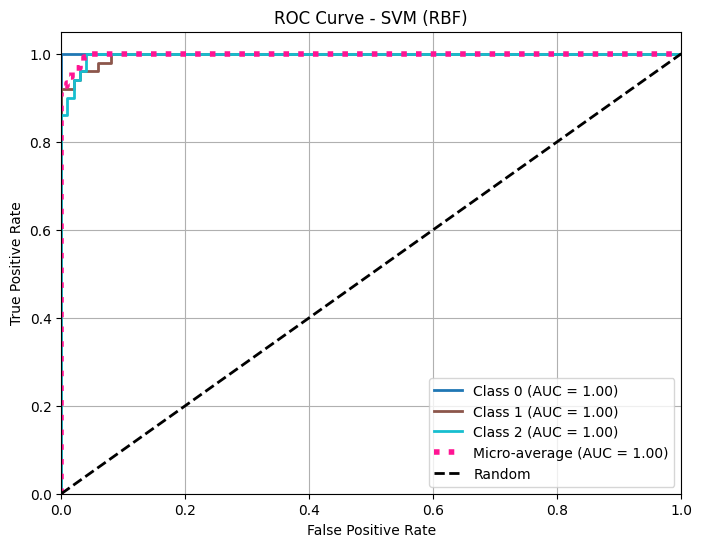


MODELO: MLP


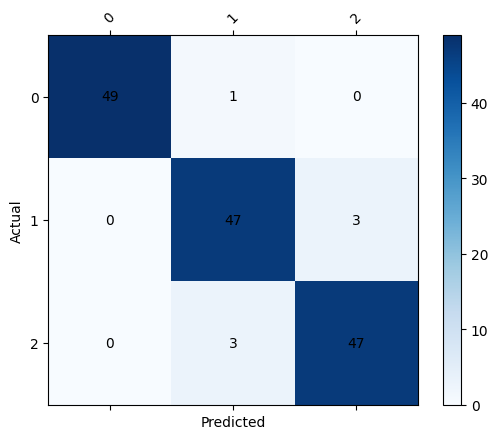

                 accuracy: 0.953333
        balanced_accuracy: 0.953333
          precision_macro: 0.953856
             recall_macro: 0.953333
                 f1_macro: 0.953531
       precision_weighted: 0.953856
          recall_weighted: 0.953333
              f1_weighted: 0.953531
                      mcc: 0.867409


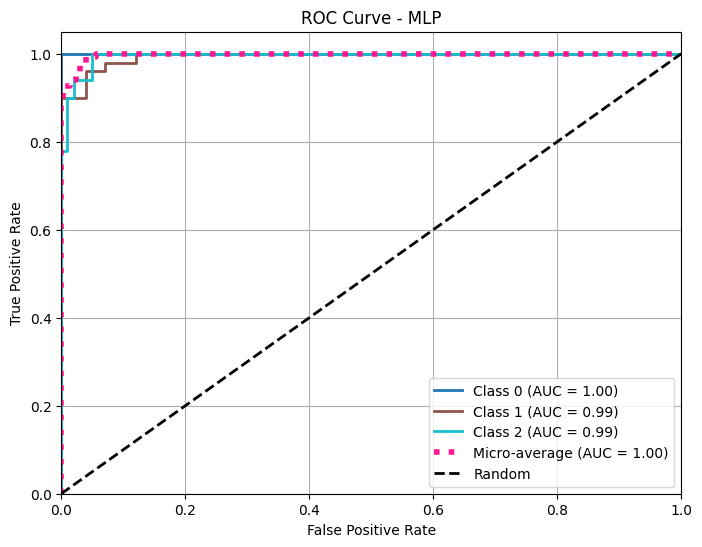


MODELO: Naive Bayes


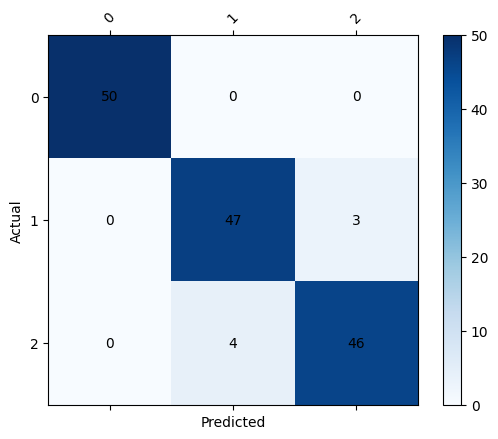

                 accuracy: 0.953333
        balanced_accuracy: 0.953333
          precision_macro: 0.953448
             recall_macro: 0.953333
                 f1_macro: 0.953329
       precision_weighted: 0.953448
          recall_weighted: 0.953333
              f1_weighted: 0.953329
                      mcc: 0.869809


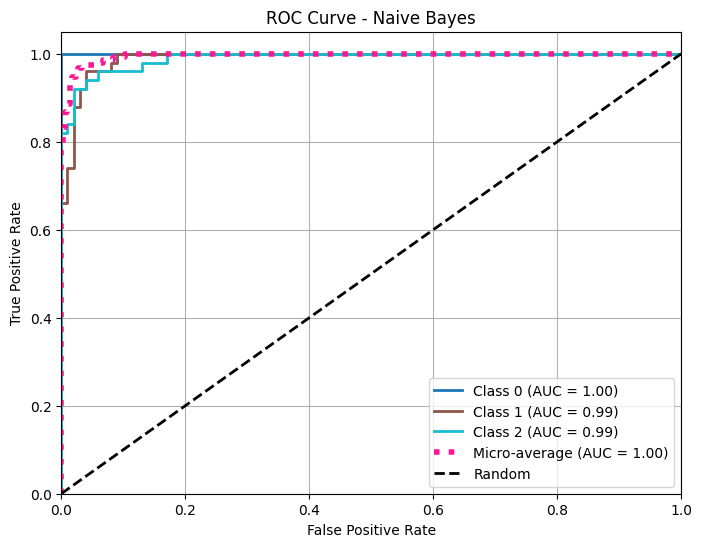


################################################################################
TABLA COMPARATIVA FINAL
################################################################################
                     accuracy  balanced_accuracy  precision_macro  \
model                                                               
Regresión Logística  0.953333           0.953333         0.953448   
SVM (RBF)            0.966667           0.966667         0.966787   
MLP                  0.953333           0.953333         0.953856   
Naive Bayes          0.953333           0.953333         0.953448   
Random Forest        0.960000           0.960000         0.960000   
KNN (k=5)            0.946667           0.946667         0.946667   
KNN (k=3)            0.946667           0.946667         0.947541   
KNN (k=1)            0.946667           0.946667         0.946667   
J48 (Entropy Tree)   0.940000           0.940000         0.940109   

                     recall_macro  f1_macro  precisio

<Figure size 1000x600 with 0 Axes>

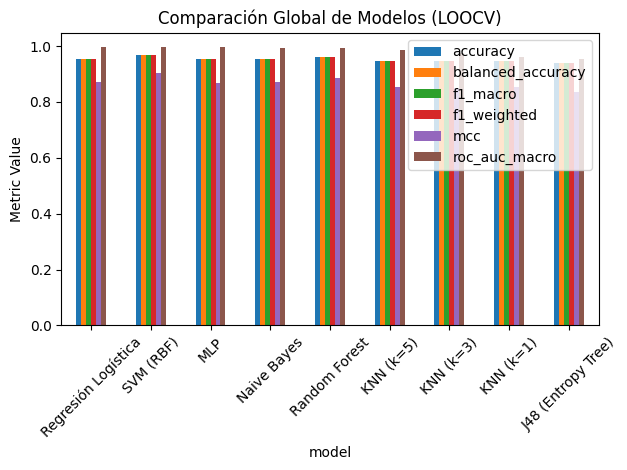

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from confusion_matrix_multiclass import (
    calculate_confusion_matrix,
    plot_confusion_matrix,
    calculate_metrics,
    plot_multiclass_roc_curve
)

SEMILLA = 666

# 1. Cargar dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
class_names = list(iris.target_names)

loo = LeaveOneOut()

# 2. Definir modelos a evaluar con scikit-learn
models = {
    "KNN (k=1)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=1))
    ]),
    "KNN (k=3)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=3))
    ]),
    "KNN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),
    "Regresión Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000))
    ]),
    "J48 (Entropy Tree)": DecisionTreeClassifier(
        criterion="entropy",
        random_state=SEMILLA
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=SEMILLA
    ),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True, random_state=SEMILLA))
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(32,16),
            max_iter=3000,
            random_state=SEMILLA
        ))
    ]),
    "Naive Bayes": GaussianNB()
}

# 3. Evaluación con LOOCV
all_results = []

for name, model in models.items():

    print("\n" + "="*80)
    print(f"MODELO: {name}")
    print("="*80)

    y_pred = cross_val_predict(model, X, y, cv=loo, method="predict")

    y_scores = cross_val_predict(model, X, y, cv=loo, method="predict_proba")

    cm, classes = calculate_confusion_matrix(y, y_pred)
    plot_confusion_matrix(cm, classes)

    metrics = calculate_metrics(cm, classes)

    for k, v in metrics.items():
        print(f"{k:>25}: {v:.6f}")

    roc_macro, roc_micro, roc_per_class = plot_multiclass_roc_curve(
        y_true=y,
        y_scores=y_scores,
        classes=classes,
        title=f"ROC Curve - {name}"
    )

    metrics["roc_auc_macro"] = roc_macro
    metrics["roc_auc_micro"] = roc_micro
    metrics["model"] = name

    all_results.append(metrics)

# 4. Tabla comparativa
df_results = pd.DataFrame(all_results)
df_results = df_results.set_index("model")

print("\n" + "#"*80)
print("TABLA COMPARATIVA FINAL")
print("#"*80)
print(df_results.sort_values(by="roc_auc_macro", ascending=False))

# 5. Graficar resultados
metrics_to_plot = [
    "accuracy",
    "balanced_accuracy",
    "f1_macro",
    "f1_weighted",
    "mcc",
    "roc_auc_macro"
]

plt.figure(figsize=(10,6))
df_results[metrics_to_plot].sort_values(
    by="roc_auc_macro",
    ascending=False
).plot(kind="bar")
plt.title("Comparación Global de Modelos (LOOCV)")
plt.ylabel("Metric Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()